In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv("BellPoints.csv")
data

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y
0,2,NaN,P1,272.890015,NaN,895.320007,-93.148845,44.461057
1,3,NaN,P2,272.820007,NaN,895.090027,-93.147879,44.460921
2,5,NaN,P3,272.989990,NaN,895.630005,-93.147206,44.460888
3,6,NaN,P4,274.089996,NaN,899.260010,-93.146881,44.459973
4,7,NaN,P5,273.880005,NaN,898.559998,-93.146947,44.458780
5,8,NaN,C1,272.579987,NaN,894.289978,-93.148845,44.461072
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,-93.147859,44.460939
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,-93.147874,44.460946
8,11,NaN,C3,272.970001,NaN,895.570007,-93.147211,44.460958
9,12,NaN,C4,272.880005,NaN,895.291016,-93.146813,44.459976


In [41]:
data2 = pd.read_csv("BellPointsDiffPos.csv")
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y,position
0,2,NaN,P1,272.890015,NaN,895.320007,488159.3105,4923094.279,"488159.310481675,4923094.27862231"
1,3,NaN,P2,272.820007,NaN,895.090027,488236.1366,4923079.035,"488236.136581651,4923079.03532231"
2,5,NaN,P3,272.989990,NaN,895.630005,488289.6405,4923075.225,"488289.640481635,4923075.22452231"
3,6,NaN,P4,274.089996,NaN,899.260010,488315.2873,4922973.533,"488315.287281626,4922973.53282234"
4,7,NaN,P5,273.880005,NaN,898.559998,488309.8092,4922841.107,"488309.809181627,4922841.10692239"
5,8,NaN,C1,272.579987,NaN,894.289978,488159.3220,4923095.989,"488159.321981676,4923095.98912231"
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.6888,4923081.029,"488237.688781651,4923081.02932231"
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.5431,4923081.750,"488236.543081652,4923081.74952231"
8,11,NaN,C3,272.970001,NaN,895.570007,488289.2422,4923083.066,"488289.242181635,4923083.06562231"
9,12,NaN,C4,272.880005,NaN,895.291016,488320.6784,4922973.887,"488320.678381624,4922973.88672234"


In [21]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [25]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import rasterio.plot
import contextily as cx
import folium

In [42]:
bell = gpd.read_file('Bell2026Shape.gpkg')
# nz_height = gpd.read_file('data/nz_height.gpkg')
# nz_elev = rasterio.open('data/nz_elev.tif')

In [43]:
bell

,AreaFT,geometry
0,530754.876708,"MULTIPOLYGON Z (((488098.348 4923122.167 0, 48..."


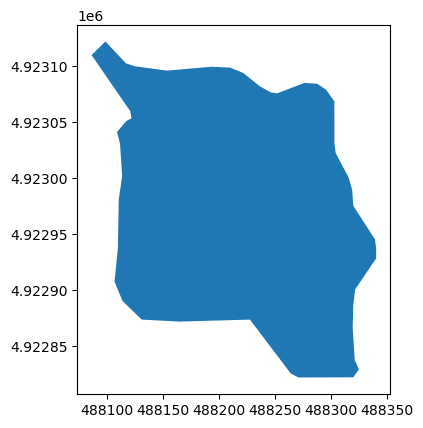

In [44]:
bell.plot();

In [45]:
data2 = gpd.GeoDataFrame(data2)
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y,position
0,2,NaN,P1,272.890015,NaN,895.320007,488159.3105,4923094.279,"488159.310481675,4923094.27862231"
1,3,NaN,P2,272.820007,NaN,895.090027,488236.1366,4923079.035,"488236.136581651,4923079.03532231"
2,5,NaN,P3,272.989990,NaN,895.630005,488289.6405,4923075.225,"488289.640481635,4923075.22452231"
3,6,NaN,P4,274.089996,NaN,899.260010,488315.2873,4922973.533,"488315.287281626,4922973.53282234"
4,7,NaN,P5,273.880005,NaN,898.559998,488309.8092,4922841.107,"488309.809181627,4922841.10692239"
5,8,NaN,C1,272.579987,NaN,894.289978,488159.3220,4923095.989,"488159.321981676,4923095.98912231"
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.6888,4923081.029,"488237.688781651,4923081.02932231"
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.5431,4923081.750,"488236.543081652,4923081.74952231"
8,11,NaN,C3,272.970001,NaN,895.570007,488289.2422,4923083.066,"488289.242181635,4923083.06562231"
9,12,NaN,C4,272.880005,NaN,895.291016,488320.6784,4922973.887,"488320.678381624,4922973.88672234"


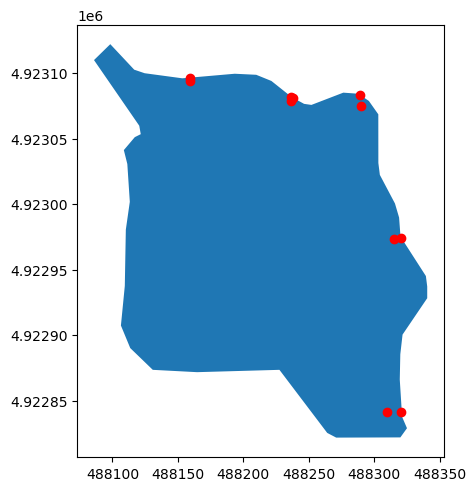

In [46]:
fig, ax = plt.subplots(layout='constrained')

bell.plot(ax=ax)
ax.scatter(data2.x, data2.y, color = "r")

plt.show();

In [52]:
from shapely import Point

In [9]:
from shapely.geometry import LineString

In [10]:
from scipy.interpolate import griddata

In [60]:
data2 = gpd.GeoDataFrame(
    data2,
    geometry=gpd.points_from_xy(data2['x'], data2['y']))

In [61]:
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y,position,geometry
0,2,NaN,P1,272.890015,NaN,895.320007,488159.3105,4923094.279,"488159.310481675,4923094.27862231",POINT (488159.31 4923094.279)
1,3,NaN,P2,272.820007,NaN,895.090027,488236.1366,4923079.035,"488236.136581651,4923079.03532231",POINT (488236.137 4923079.035)
2,5,NaN,P3,272.989990,NaN,895.630005,488289.6405,4923075.225,"488289.640481635,4923075.22452231",POINT (488289.64 4923075.225)
3,6,NaN,P4,274.089996,NaN,899.260010,488315.2873,4922973.533,"488315.287281626,4922973.53282234",POINT (488315.287 4922973.533)
4,7,NaN,P5,273.880005,NaN,898.559998,488309.8092,4922841.107,"488309.809181627,4922841.10692239",POINT (488309.809 4922841.107)
5,8,NaN,C1,272.579987,NaN,894.289978,488159.3220,4923095.989,"488159.321981676,4923095.98912231",POINT (488159.322 4923095.989)
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.6888,4923081.029,"488237.688781651,4923081.02932231",POINT (488237.689 4923081.029)
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.5431,4923081.750,"488236.543081652,4923081.74952231",POINT (488236.543 4923081.75)
8,11,NaN,C3,272.970001,NaN,895.570007,488289.2422,4923083.066,"488289.242181635,4923083.06562231",POINT (488289.242 4923083.066)
9,12,NaN,C4,272.880005,NaN,895.291016,488320.6784,4922973.887,"488320.678381624,4922973.88672234",POINT (488320.678 4922973.887)


<function matplotlib.pyplot.show(close=None, block=None)>

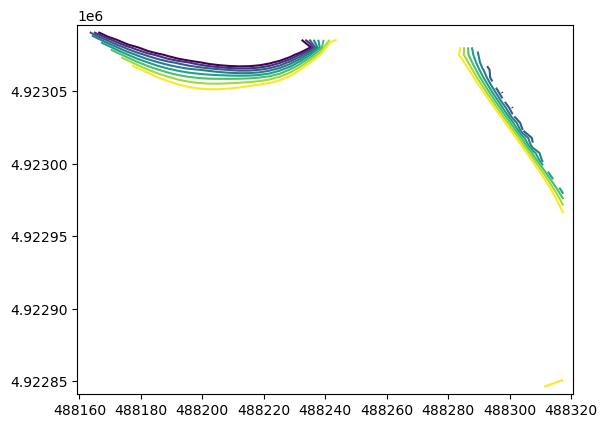

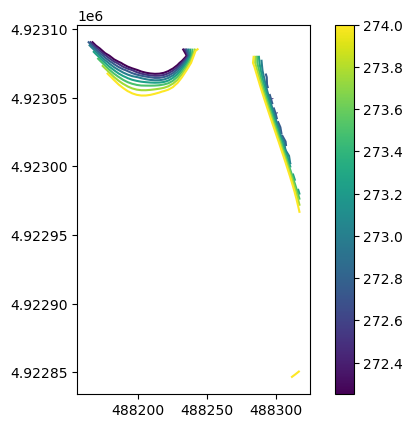

In [66]:
# from google gemnini and I don't fully understand
x = data2.x
y = data2.y
z = data2["WaterElevation"]

# I think this is interpolating the data in data2 onto a grif because it's essentially random points scattered around random space as is
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max()), 
    np.linspace(y.min(), y.max())
)
grid_z = griddata((x, y), z , (grid_x, grid_y), method = 'cubic')

levels = np.arange(z.min(), z.max(), 0.25) #0.25 is the contour interval
cs = plt.contour(grid_x, grid_y, grid_z, levels=levels)

lines = []
for level, segments in zip(cs.levels, cs.allsegs):
    for line in segments:
        if len(line) >= 2:
            lines.append({'head': level, 'geometry': LineString(line)})

contour_data2 = gpd.GeoDataFrame(lines, crs = data2.crs)

contour_data2.plot(column='head', cmap='viridis', legend=True)
plt.show

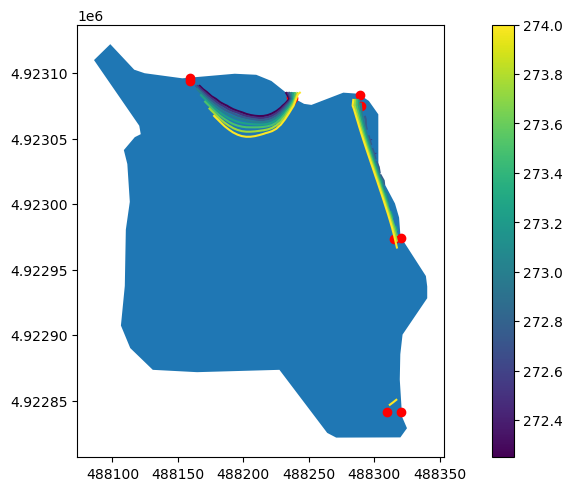

In [67]:
fig, ax = plt.subplots(layout='constrained')

bell.plot(ax=ax)
ax.scatter(data2.x, data2.y, color = "r")
contour_data2.plot(ax=ax, column='head', cmap='viridis', legend=True)

plt.show();